In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd
import pickle

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../artificial_simulator/proactive_conformance_check/repair_shop_event_log_conf_dev.csv'

result_name = 'repair_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               'org:resource'
              ]

# static categorical attributes
cat_static = []

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               ]

# dynamic log-normal encoded numerical attributes 
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 3

train_validation_size = 0.3
# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        'train_validation_size' : train_validation_size,
                        'test_validation_size' :test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

unique_vals = (
    pd.Series(raw_data["concept:name"])
      .explode()
      .dropna()
      .unique()
      .tolist()
)

print(unique_vals)

['RECEPTION', 'DISASSEMBLY', 'ACKNOWLEDGEMENT', 'REPAIR', 'QUALITY_CONTROL', 'CREATE_INVOICE', 'SHIPPING']


In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,c1,1,[RECEPTION],[46],[0.0],[nan],[2.0],[29626.0]
1,c1,2,"[RECEPTION, DISASSEMBLY]","[46, 38]","[0.0, 16542.962890625]","[nan, 16542.962890625]","[2.0, 2.0]","[29626.0, 46169.0]"
2,c1,3,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT]","[46, 38, 5]","[0.0, 16542.962890625, 17845.3125]","[nan, 16542.962890625, 1302.349609375]","[2.0, 2.0, 2.0]","[29626.0, 46169.0, 47471.0]"
3,c1,4,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPAIR]","[46, 38, 5, 42]","[0.0, 16542.962890625, 17845.3125, 25915.53710...","[nan, 16542.962890625, 1302.349609375, 8070.22...","[2.0, 2.0, 2.0, 2.0]","[29626.0, 46169.0, 47471.0, 55541.0]"
4,c1,5,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPA...","[46, 38, 5, 42, 14]","[0.0, 16542.962890625, 17845.3125, 25915.53710...","[nan, 16542.962890625, 1302.349609375, 8070.22...","[2.0, 2.0, 2.0, 2.0, 2.0]","[29626.0, 46169.0, 47471.0, 55541.0, 63181.0]"
...,...,...,...,...,...,...,...,...
45208,c9973,2,"[RECEPTION, DISASSEMBLY]","[9, 36]","[0.0, 21773.33984375]","[nan, 21773.33984375]","[4.0, 4.0]","[50017.0, 71790.0]"
45209,c9973,3,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT]","[9, 36, 22]","[0.0, 21773.33984375, 23108.544921875]","[nan, 21773.33984375, 1335.2047119140625]","[4.0, 4.0, 4.0]","[50017.0, 71790.0, 73126.0]"
45210,c9974,1,[RECEPTION],[14],[0.0],[nan],[4.0],[63087.0]
45211,c9976,1,[RECEPTION],[31],[0.0],[nan],[4.0],[66683.0]


In [7]:
train_pref_df.to_csv('../../../../encoded_data_conformance_v2/Repair/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,c0,1,[RECEPTION],[27],[0.0],[nan],[2.0],[25605.0]
1,c0,2,"[RECEPTION, DISASSEMBLY]","[27, 23]","[0.0, 18427.859375]","[nan, 18427.859375]","[2.0, 2.0]","[25605.0, 44033.0]"
2,c0,3,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT]","[27, 23, 45]","[0.0, 18427.859375, 20003.595703125]","[nan, 18427.859375, 1575.7362060546875]","[2.0, 2.0, 2.0]","[25605.0, 44033.0, 45608.0]"
3,c0,4,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPAIR]","[27, 23, 45, 10]","[0.0, 18427.859375, 20003.595703125, 34505.382...","[nan, 18427.859375, 1575.7362060546875, 14501....","[2.0, 2.0, 2.0, 2.0]","[25605.0, 44033.0, 45608.0, 60110.0]"
4,c0,5,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPA...","[27, 23, 45, 10, 45]","[0.0, 18427.859375, 20003.595703125, 34505.382...","[nan, 18427.859375, 1575.7362060546875, 14501....","[2.0, 2.0, 2.0, 2.0, 2.0]","[25605.0, 44033.0, 45608.0, 60110.0, 68581.0]"
...,...,...,...,...,...,...,...,...
24658,c9971,3,"[RECEPTION, ACKNOWLEDGEMENT, DISASSEMBLY]","[12, 36, 49]","[0.0, 36985.296875, 61333.546875]","[nan, 36985.296875, 24348.25]","[3.0, 4.0, 4.0]","[80515.0, 31100.0, 55448.0]"
24659,c9971,4,"[RECEPTION, ACKNOWLEDGEMENT, DISASSEMBLY, REPAIR]","[12, 36, 49, 27]","[0.0, 36985.296875, 61333.546875, 68295.4765625]","[nan, 36985.296875, 24348.25, 6961.93212890625]","[3.0, 4.0, 4.0, 4.0]","[80515.0, 31100.0, 55448.0, 62410.0]"
24660,c9972,1,[RECEPTION],[33],[0.0],[nan],[4.0],[25524.0]
24661,c9972,2,"[RECEPTION, DISASSEMBLY]","[33, 48]","[0.0, 20864.5078125]","[nan, 20864.5078125]","[4.0, 4.0]","[25524.0, 46389.0]"


In [9]:
val_pref_df.to_csv('../../../../encoded_data_conformance_v2/Repair/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,c4,1,[RECEPTION],[8],[0.0],[nan],[3.0],[55517.0]
1,c4,2,"[RECEPTION, DISASSEMBLY]","[8, 33]","[0.0, 21227.716796875]","[nan, 21227.716796875]","[3.0, 3.0]","[55517.0, 76744.0]"
2,c4,3,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT]","[8, 33, 15]","[0.0, 21227.716796875, 44394.60546875]","[nan, 21227.716796875, 23166.88671875]","[3.0, 3.0, 4.0]","[55517.0, 76744.0, 13511.0]"
3,c4,4,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPAIR]","[8, 33, 15, 3]","[0.0, 21227.716796875, 44394.60546875, 69240.5...","[nan, 21227.716796875, 23166.88671875, 24845.9...","[3.0, 3.0, 4.0, 4.0]","[55517.0, 76744.0, 13511.0, 38357.0]"
4,c4,5,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT, REPA...","[8, 33, 15, 3, 17]","[0.0, 21227.716796875, 44394.60546875, 69240.5...","[nan, 21227.716796875, 23166.88671875, 24845.9...","[3.0, 3.0, 4.0, 4.0, 4.0]","[55517.0, 76744.0, 13511.0, 38357.0, 44903.0]"
...,...,...,...,...,...,...,...,...
12361,c9963,9,"[RECEPTION, ACKNOWLEDGEMENT, DISASSEMBLY, REPA...","[33, 6, 8, 11, 37, 45, 45, 23, 15]","[0.0, 6812.39111328125, 18597.556640625, 31270...","[nan, 6812.39111328125, 11785.1650390625, 1267...","[2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0]","[42542.0, 49355.0, 61140.0, 73813.0, 28472.0, ..."
12362,c9970,1,[RECEPTION],[40],[0.0],[nan],[3.0],[72173.0]
12363,c9970,2,"[RECEPTION, DISASSEMBLY]","[40, 42]","[0.0, 56879.06640625]","[nan, 56879.06640625]","[3.0, 4.0]","[72173.0, 42652.0]"
12364,c9970,3,"[RECEPTION, DISASSEMBLY, ACKNOWLEDGEMENT]","[40, 42, 45]","[0.0, 56879.06640625, 65077.3671875]","[nan, 56879.06640625, 8198.298828125]","[3.0, 4.0, 4.0]","[72173.0, 42652.0, 50851.0]"


In [11]:
test_pref_df.to_csv('../../../../encoded_data_conformance_v2/Repair/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [12]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["case:concept:name"].dropna().unique().tolist()
unique_list_val = val_pref_df["case:concept:name"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

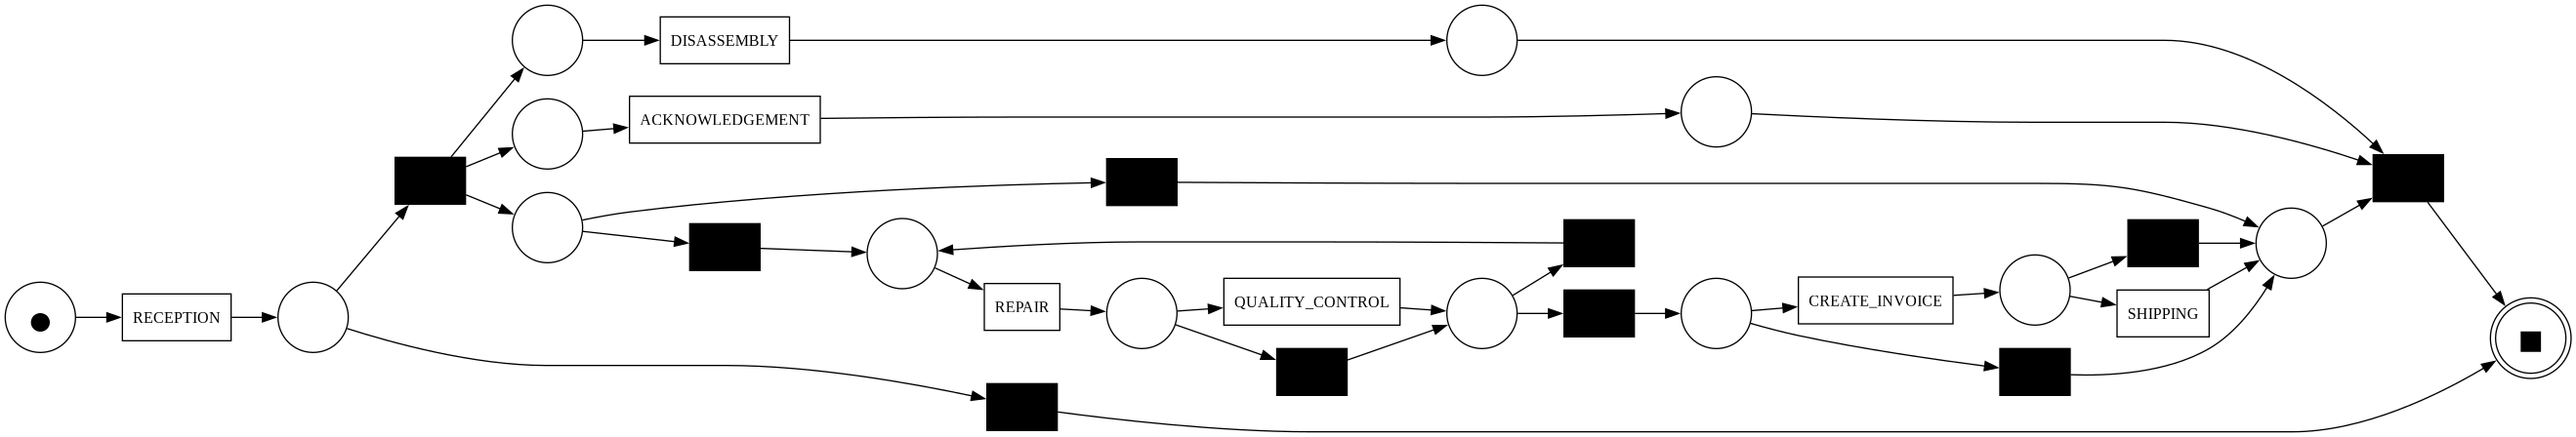

In [13]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
store_loc_file_path ='../../../../encoded_data_conformance_v2/Repair/prefix_for_replay/petri_net/bpic20_DD.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

In [14]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  45213


,marking,count
0,[p_3],5489
1,"[p_7, p_5, p_13]",4766
2,"[p_7, p_5, p_12]",4045
3,"[p_5, p_7, p_12]",3376
4,"[p_5, p_7, p_13]",3286
5,"[p_6, p_8, p_5]",2825
6,"[p_4, p_8, p_7]",2661
7,"[p_8, p_7, p_5]",2661
8,"[p_7, p_5, p_15]",2661
9,"[p_7, p_5, p_9]",2660


In [15]:
# validation set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  24663


,marking,count
0,[p_3],2993
1,"[p_7, p_5, p_13]",2654
2,"[p_7, p_5, p_12]",2263
3,"[p_5, p_7, p_12]",1793
4,"[p_5, p_7, p_13]",1752
5,"[p_6, p_8, p_5]",1508
6,"[p_8, p_7, p_5]",1485
7,"[p_4, p_8, p_7]",1485
8,"[p_7, p_5, p_9]",1484
9,"[p_7, p_5, p_15]",1484


In [16]:
# test set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  12366


,marking,count
0,[p_3],1496
1,"[p_7, p_5, p_13]",1349
2,"[p_7, p_5, p_12]",1153
3,"[p_5, p_7, p_12]",910
4,"[p_5, p_7, p_13]",874
5,"[p_8, p_7, p_5]",757
6,"[p_4, p_8, p_7]",757
7,"[p_7, p_5, p_9]",757
8,"[p_7, p_5, p_15]",757
9,"[p_6, p_8, p_5]",739


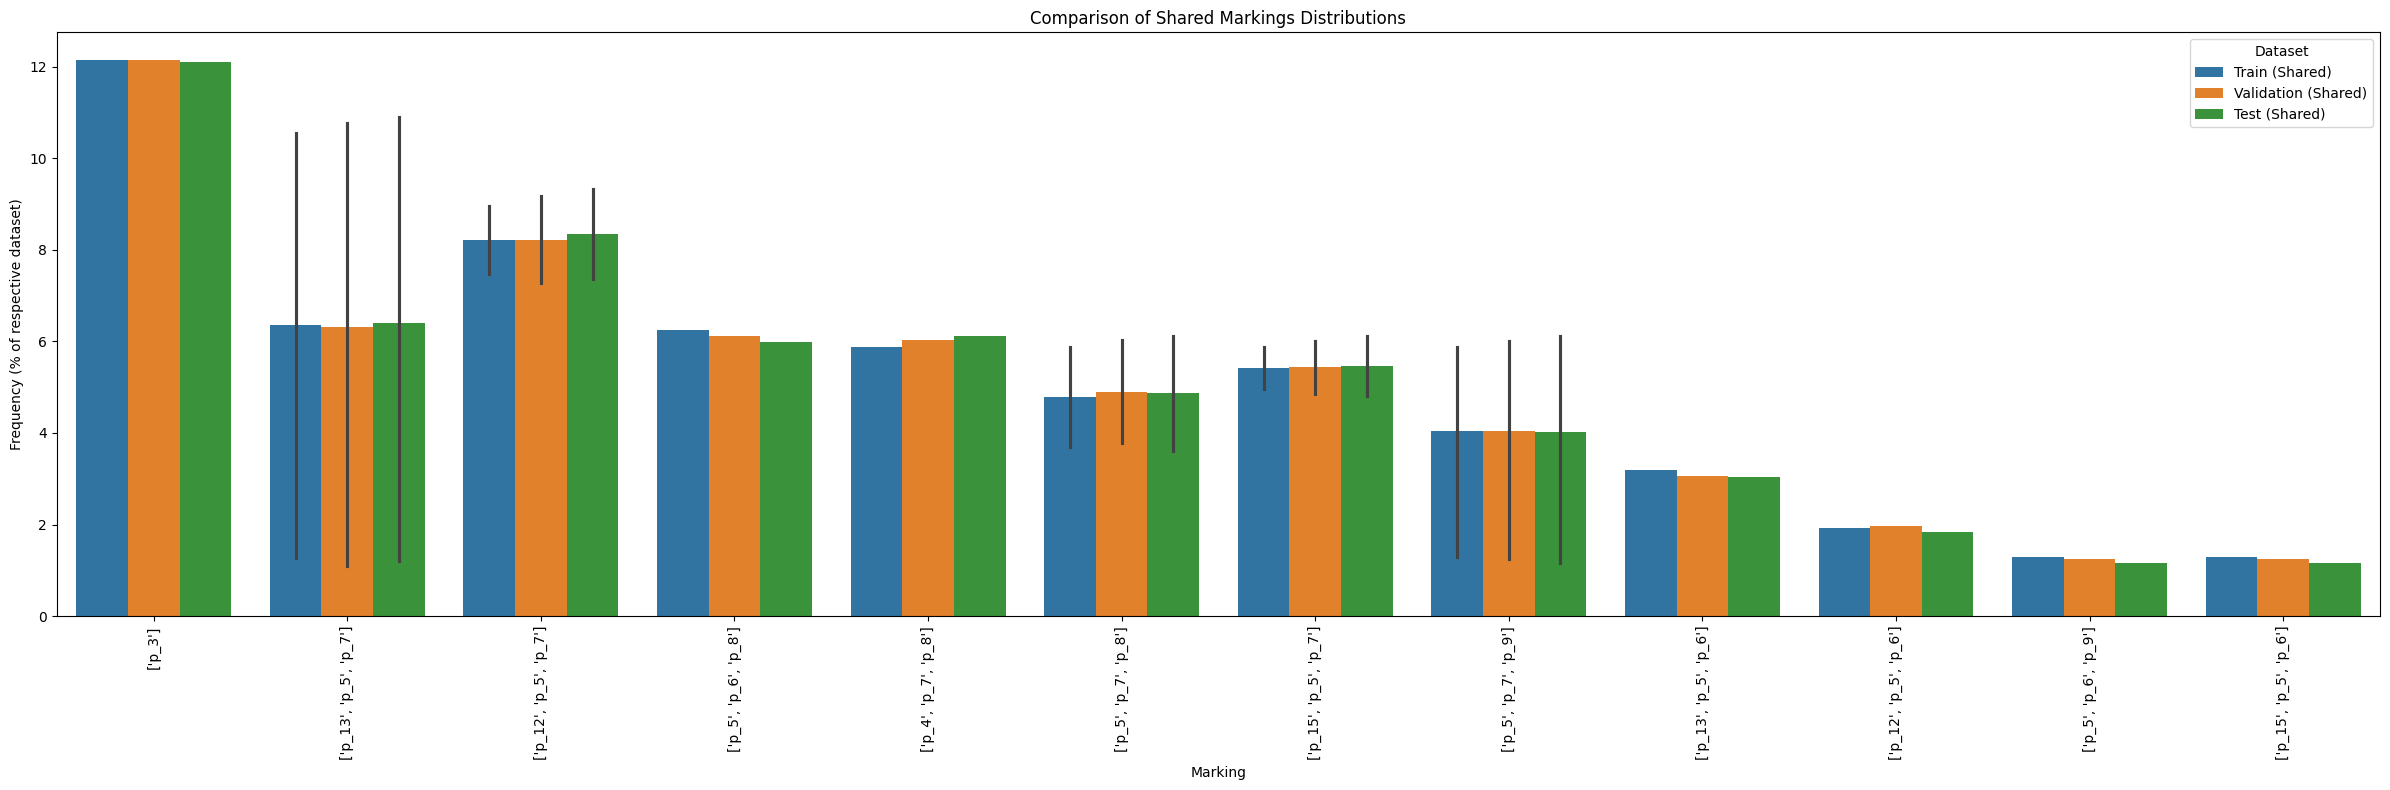

No unique markings found across datasets.


<Figure size 2400x800 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# Plot 1: Shared Markings
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Unique Markings
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

In [18]:
# Remove prefixes whose Petri net marking is unique to one split (Train/Val/Test)
"""
print("All prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))

(train_pref_df,
 val_pref_df,
 test_pref_df,
 markings_train,
 markings_val,
 markings_test,
 (keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,
                                                                                                        val_pref_df,
                                                                                                        test_pref_df,
                                                                                                        markings_train,
                                                                                                        markings_val,
                                                                                                        markings_test)


print("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))
"""

'\nprint("All prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))\n\n(train_pref_df,\n val_pref_df,\n test_pref_df,\n markings_train,\n markings_val,\n markings_test,\n (keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,\n                                                                                                        val_pref_df,\n                                                                                                        test_pref_df,\n                                                                                                        markings_train,\n                                                                                                        markings_val,\n                                                                                                        markings_test)\n\n\nprint("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df)

## Dtore datasets and credentials for Deep-NN

In [19]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [20]:
# test
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,case:concept:name,concept:name,a:id,time:timestamp,org:resource,type,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,c4,RECEPTION,0.0,2020-01-02 15:25:17.229621,8,EventType.ACTIVITY_COMPLETE,0.000000,NaN,3.0,55517.0
1,c4,DISASSEMBLY,1.0,2020-01-02 21:19:04.947235,33,EventType.ACTIVITY_COMPLETE,21227.716797,21227.716797,3.0,76744.0
2,c4,ACKNOWLEDGEMENT,2.0,2020-01-03 03:45:11.834140,15,EventType.ACTIVITY_COMPLETE,44394.605469,23166.886719,4.0,13511.0
3,c4,REPAIR,3.0,2020-01-03 10:39:17.786769,3,EventType.ACTIVITY_COMPLETE,69240.554688,24845.953125,4.0,38357.0
4,c4,QUALITY_CONTROL,4.0,2020-01-03 12:28:23.819858,17,EventType.ACTIVITY_COMPLETE,75786.593750,6546.033203,4.0,44903.0
...,...,...,...,...,...,...,...,...,...,...
16849,c9970,ACKNOWLEDGEMENT,2.0,2025-06-20 14:07:31.126930,45,EventType.ACTIVITY_COMPLETE,65077.367188,8198.298828,4.0,50851.0
16850,c9970,REPAIR,3.0,2025-06-20 16:56:23.874544,45,EventType.ACTIVITY_COMPLETE,75210.117188,10132.748047,4.0,60983.0
16851,c9970,EOS,NaN,NaT,EOS,NaN,NaN,NaN,NaN,NaN
16852,c9970,EOS,NaN,NaT,EOS,NaN,NaN,NaN,NaN,NaN


In [21]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformance_v2/Repair/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

concept:name:   0%|          | 0/5489 [00:00<?, ?it/s]

org:resource:   0%|          | 0/5489 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/5489 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/5489 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/5489 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/5489 [00:00<?, ?it/s]

In [22]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  3
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 9, {'ACKNOWLEDGEMENT': 1, 'CREATE_INVOICE': 2, 'DISASSEMBLY': 3, 'EOS': 4, 'QUALITY_CONTROL': 5, 'RECEPTION': 6, 'REPAIR': 7, 'SHIPPING': 8}), ('org:resource', 52, {'0': 1, '1': 2, '10': 3, '11': 4, '12': 5, '13': 6, '14': 7, '15': 8, '16': 9, '17': 10, '18': 11, '19': 12, '2': 13, '20': 14, '21': 15, '22': 16, '23': 17, '24': 18, '25': 19, '26': 20, '27': 21, '28': 22, '29': 23, '3': 24, '30': 25, '31': 26, '32': 27, '33': 28, '34': 29, '35': 30, '36': 31, '37': 32, '38': 33, '39': 34, '4': 35, '40': 36, '41': 37, '42': 38, '43': 39, '44': 40, '45': 41, '46': 42, '47': 43, '48': 44, '49': 45, '5': 46, '6': 47, '7': 48, '8': 49, '9': 50, 'EOS': 51})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([], [])
Dynamic categorical t

In [23]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformance_v2/Repair/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

concept:name:   0%|          | 0/2993 [00:00<?, ?it/s]

org:resource:   0%|          | 0/2993 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/2993 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/2993 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/2993 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/2993 [00:00<?, ?it/s]

In [24]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  3
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 9, {'ACKNOWLEDGEMENT': 1, 'CREATE_INVOICE': 2, 'DISASSEMBLY': 3, 'EOS': 4, 'QUALITY_CONTROL': 5, 'RECEPTION': 6, 'REPAIR': 7, 'SHIPPING': 8}), ('org:resource', 52, {'0': 1, '1': 2, '10': 3, '11': 4, '12': 5, '13': 6, '14': 7, '15': 8, '16': 9, '17': 10, '18': 11, '19': 12, '2': 13, '20': 14, '21': 15, '22': 16, '23': 17, '24': 18, '25': 19, '26': 20, '27': 21, '28': 22, '29': 23, '3': 24, '30': 25, '31': 26, '32': 27, '33': 28, '34': 29, '35': 30, '36': 31, '37': 32, '38': 33, '39': 34, '4': 35, '40': 36, '41': 37, '42': 38, '43': 39, '44': 40, '45': 41, '46': 42, '47': 43, '48': 44, '49': 45, '5': 46, '6': 47, '7': 48, '8': 49, '9': 50, 'EOS': 51})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([], [])
Dynamic categorical t

In [26]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformance_v2/Repair/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1496 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1496 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/1496 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/1496 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1496 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1496 [00:00<?, ?it/s]

In [ ]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])